In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as hf
import jax.numpy as jnp
import jax
import seaborn as sns

In [2]:
def compute_rdf(position_data: np.ndarray, reference_data):
    """
    Compute an rdf on colloids positions w.r.t the rod center.
    
    Parameters
    ----------
    data : np.ndarray (time_steps, colloids, 3)
    """
    # Convert to polar coordinates
    def inner_fn(
        position: jnp.ndarray, reference
    ):
        origin = jnp.array([500., 500., 0.])
        distance_vector = position - origin
        distance = jnp.linalg.norm(distance_vector)
        normed_distance = distance_vector / distance
        
        angle = jnp.arctan2(
            normed_distance[0] * reference[1] - normed_distance[1] * reference[0],
            normed_distance[0] * reference[0] + normed_distance[1] * reference[1]
        )
        return jnp.array([distance, angle])
    
    mapped_fn = jax.vmap(inner_fn, in_axes=(0, None))
    
    outer_map_fn = jax.vmap(mapped_fn, in_axes=(0, 0))
    
    polar_coordinates = outer_map_fn(
        position_data, reference_data
    )
    
    # Convert to cartesian coordinates
    def inner_fn(
        distance: jnp.ndarray, angle: jnp.ndarray
    ):
        x = distance * jnp.cos(angle)
        y = distance * jnp.sin(angle)
        
        return jnp.array([x, y])
    
    mapped_fn = jax.vmap(inner_fn, in_axes=(0, 0))
    
    outer_map_fn = jax.vmap(mapped_fn, in_axes=(0, 0))
    
    cartesian_coords = outer_map_fn(
        polar_coordinates[:, :, 0], polar_coordinates[:, :, 1]
    )
        
    return cartesian_coords  

In [42]:
def net_rdf_compute(temp, indices):
    all_coords = []
    for i in indices:
        with hf.File(f"{temp}/{i}/deployment/trajectory.hdf5", "r") as db:
            colloid_positions = db["colloids"]["Unwrapped_Positions"][:, :30, :]    
            rod_references = db["colloids"]["Directors"][:, 50, :]

        all_coords.append(compute_rdf(colloid_positions, rod_references))
        
    return all_coords

In [43]:
results = {
    "0K": {"indices": [1, 2, 5, 6, 7, 9, 10]},
    "150K": {"indices": [1, 2, 4, 5, 6, 8, 9, 10]},
    "273K": {"indices": [1, 3, 4, 5, 7, 8, 9, 10]},
    "300K": {"indices": [1, 2, 5, 6, 7, 8, 9, 10]},
    "350K": {"indices": [1, 2, 4, 5, 6, 7, 8, 10]},
}

for temp in results:
    print(temp)
    rdf_data = np.hstack(net_rdf_compute(temp, indices=results[temp]["indices"]))
    results[temp]["rdf_data"] = rdf_data

0K
150K
273K
300K
350K


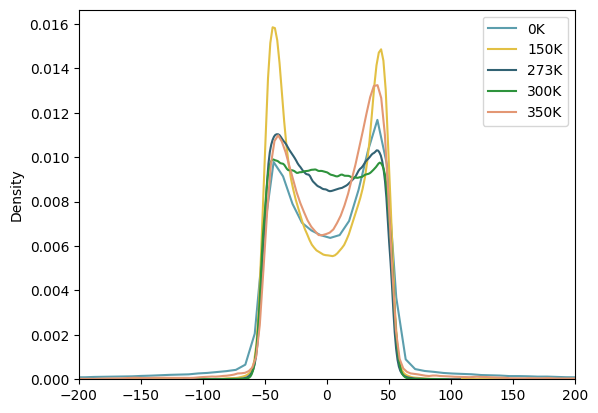

In [53]:
colors = ["#5c9ead","#e2c044","#326273","#2e933c","#e39774"]
temps = list(results)

for i in range(len(temps)):
    sns.kdeplot(
        x=results[temps[i]]["rdf_data"][::10, :, 0].flatten(), color=colors[i], label=temps[i]
    )
      
plt.xlim(-200, 200)
# plt.ylim(-200, 200)
plt.legend()
plt.show()

In [44]:
np.save("hist_data.npy", results)